In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
import os

warnings.filterwarnings('ignore')

# Set working directory to project root
os.chdir('/home/code0053/news-sentiment-analysis')

# Plot styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("All libraries loaded successfully!")
print("Working directory:", os.getcwd())

All libraries loaded successfully!
Working directory: /home/code0053/news-sentiment-analysis


In [3]:
# Cell 2: Load News Dataset
df = pd.read_csv('data/raw/raw_analyst_ratings.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1407328, 6)

Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [4]:
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum():,}")

print("\n=== Sample Headlines ===")
print(df['headline'].sample(5).values)

=== Dataset Shape ===
Rows: 1,407,328 | Columns: 6

=== Missing Values ===
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

=== Duplicate Rows ===
Duplicates: 0

=== Sample Headlines ===
['Delta Takes Stake In LATAM Airlines'
 "Benzinga's Top Upgrades, Downgrades For March 7, 2017"
 'Option Alert: Peabody Energy Sep $1.5 Call Sweep; 10,000 Contracts @Ask @$0.50'
 'Stocks Which Set New 52-Week Low The Last Trading Session, Fri., Dec. 7, 2018'
 'Pending Home Sales Rebound 10.4% in October']


=== Headline Character Count Stats ===
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

=== Word Count Stats ===
count    1.407328e+06
mean     1.141671e+01
std      6.352997e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      7.700000e+01
Name: word_count, dtype: float64


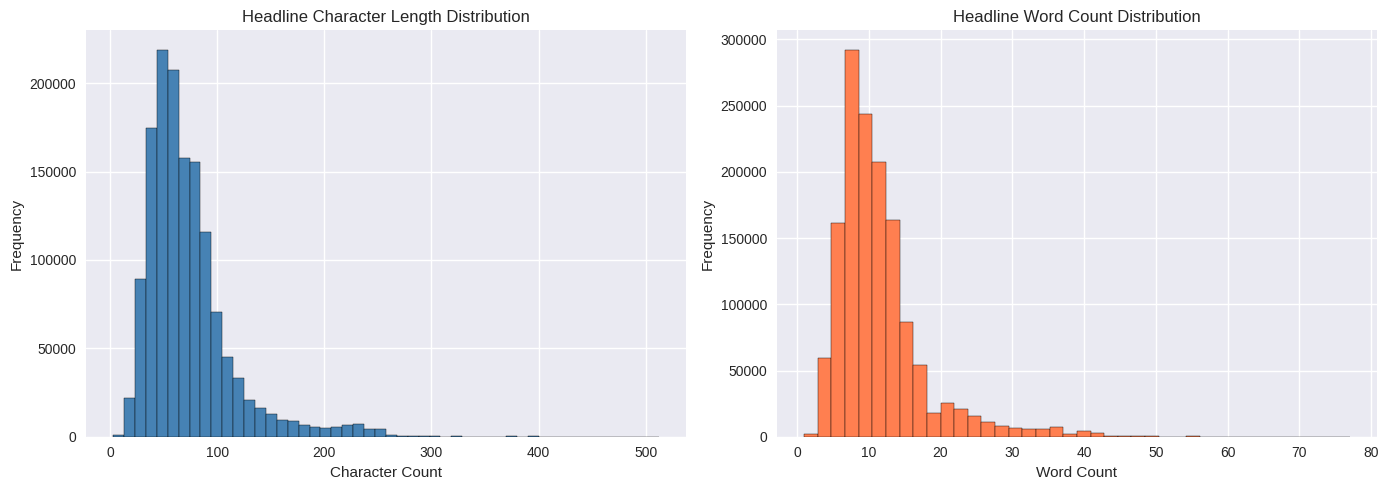

Plot saved!


In [5]:
# Cell 4: Headline Length Analysis
df['headline_length'] = df['headline'].astype(str).apply(len)
df['word_count'] = df['headline'].astype(str).apply(lambda x: len(x.split()))

print("=== Headline Character Count Stats ===")
print(df['headline_length'].describe())

print("\n=== Word Count Stats ===")
print(df['word_count'].describe())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['headline_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Headline Character Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='black')
axes[1].set_title('Headline Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('notebooks/headline_length_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

=== Top 20 Most Active Publishers ===
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64


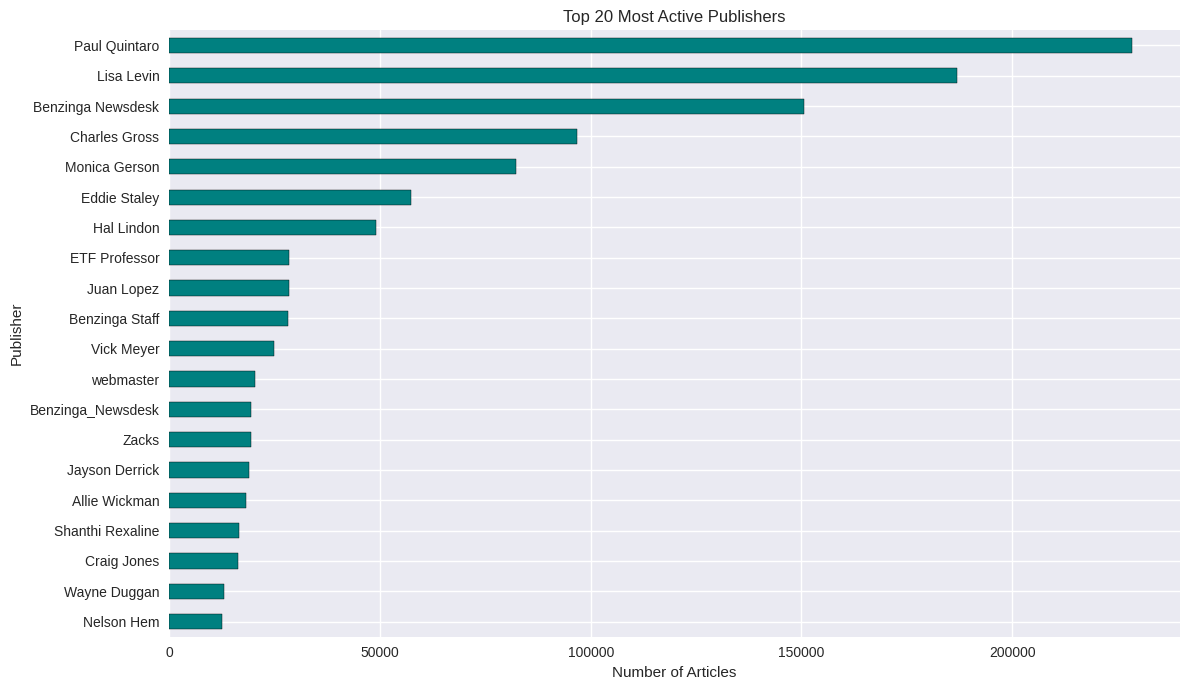

Plot saved!


In [6]:
# Cell 5: Publisher Analysis
# Top 20 publishers
top_publishers = df['publisher'].value_counts().head(20)

print("=== Top 20 Most Active Publishers ===")
print(top_publishers)

# Plot
plt.figure(figsize=(12, 7))
top_publishers.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 20 Most Active Publishers')
plt.xlabel('Number of Articles')
plt.ylabel('Publisher')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('notebooks/top_publishers.png', dpi=150)
plt.show()
print("Plot saved!")

=== Top 30 Keywords/Phrases in Headlines ===
vs                                162,099
stocks                            161,776
est                               140,604
eps                               128,897
market                            120,558
shares                            114,313
reports                           108,710
update                             91,723
earnings                           87,399
sales                              79,645
benzinga                           74,516
pt                                 73,068
week                               69,572
announces                          66,591
price                              64,407
buy                                64,371
mid                                62,263
downgrades                         61,959
trading                            61,182
raises                             57,802
52                                 56,972
upgrades                           56,811
target                         

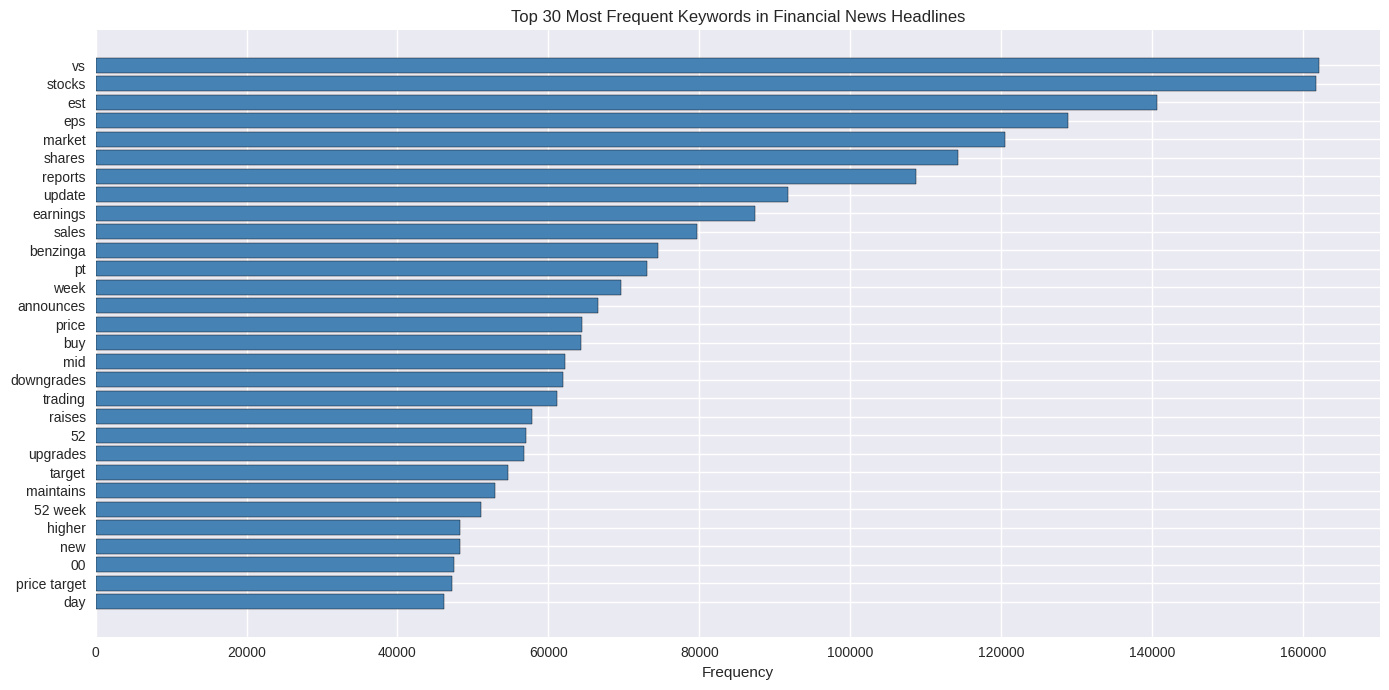

Plot saved!


In [9]:
# Cell 7: Keyword and Topic Analysis
from sklearn.feature_extraction.text import CountVectorizer

# Clean headlines
headlines = df['headline'].astype(str).tolist()

# Top keywords using CountVectorizer
vectorizer = CountVectorizer(
    max_features=30,
    stop_words='english',
    ngram_range=(1, 2)  # single words and bigrams
)

X = vectorizer.fit_transform(headlines)
word_freq = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
word_freq_sorted = dict(sorted(word_freq.items(), key=lambda x: x[1], reverse=True))

print("=== Top 30 Keywords/Phrases in Headlines ===")
for word, freq in word_freq_sorted.items():
    print(f"{word:30s} {freq:>10,}")

# Plot
plt.figure(figsize=(14, 7))
plt.barh(list(word_freq_sorted.keys()), list(word_freq_sorted.values()), color='steelblue', edgecolor='black')
plt.title('Top 30 Most Frequent Keywords in Financial News Headlines')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('notebooks/top_keywords.png', dpi=150)
plt.show()
print("Plot saved!")

=== Top 20 Most Covered Stocks ===
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
Name: count, dtype: int64


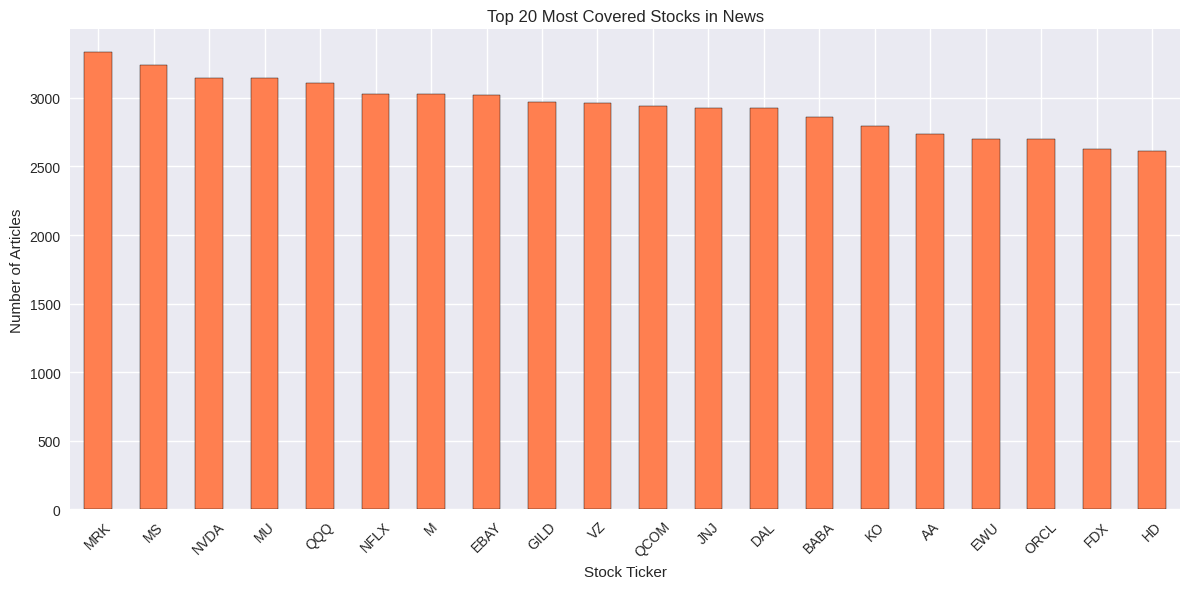

Plot saved!


In [10]:
# Cell 8: Most Covered Stocks
top_stocks = df['stock'].value_counts().head(20)

print("=== Top 20 Most Covered Stocks ===")
print(top_stocks)

plt.figure(figsize=(12, 6))
top_stocks.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 20 Most Covered Stocks in News')
plt.xlabel('Stock Ticker')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('notebooks/top_stocks_coverage.png', dpi=150)
plt.show()
print("Plot saved!")

In [11]:
# Cell 9: Publisher Domain Analysis
def extract_domain(publisher):
    if '@' in str(publisher):
        return str(publisher).split('@')[-1]
    return str(publisher)

df['publisher_domain'] = df['publisher'].apply(extract_domain)

top_domains = df['publisher_domain'].value_counts().head(15)
print("=== Top 15 Publisher Domains ===")
print(top_domains)

=== Top 15 Publisher Domains ===
publisher_domain
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


=== Articles Per Year ===
year
2009     11489
2010     81319
2011    131322
2012    122649
2013    121529
2014    134859
2015    135295
2016    141892
2017    124456
2018    146924
2019    150380
2020    105214
dtype: int64


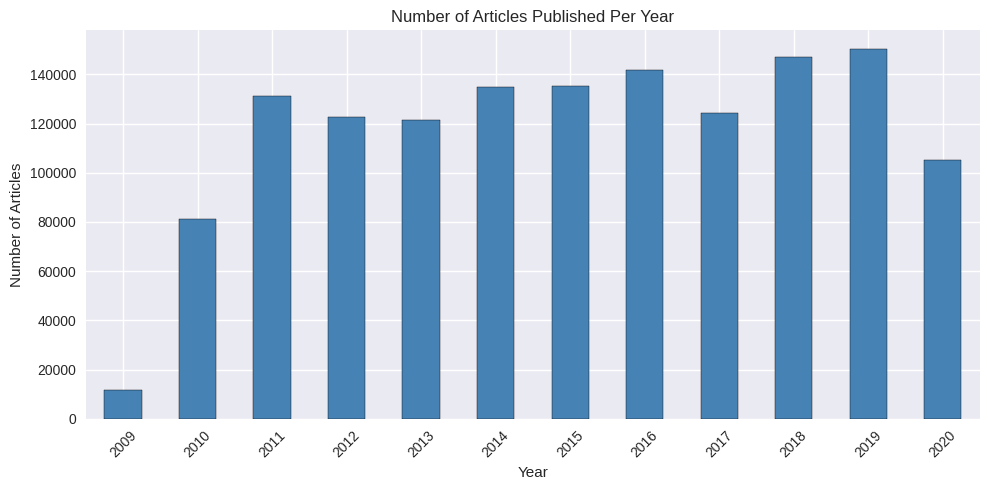

Plot saved!


In [14]:
# Cell 10: Articles per Year - Fixed date parsing
df['date'] = pd.to_datetime(df['date'], format='mixed', utc=True)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['date_only'] = df['date'].dt.date

yearly_counts = df.groupby('year').size()

print("=== Articles Per Year ===")
print(yearly_counts)

plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Articles Published Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('notebooks/articles_per_year.png', dpi=150)
plt.show()
print("Plot saved!")

In [15]:
# Cell 11: Save cleaned dataframe
df.to_csv('data/raw/cleaned_news.csv', index=False)
print("Cleaned dataset saved!")
print(f"Final shape: {df.shape}")
print(f"\nNew columns added: {['headline_length', 'word_count', 'date_only', 'year', 'month', 'hour', 'day_of_week', 'publisher_domain']}")

Cleaned dataset saved!
Final shape: (1407328, 14)

New columns added: ['headline_length', 'word_count', 'date_only', 'year', 'month', 'hour', 'day_of_week', 'publisher_domain']
